# Task 2: Quantitative Analysis - Technical Indicators
In this notebook, we apply technical analysis to historical stock price data for major tech companies. The goal is to move beyond raw prices and identify trends, momentum, and potential reversal points using mathematical indicators.

In [1]:
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Style settings
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 10)

# Load data
data_dir = '../data/raw'
stock_files = [f for f in glob.glob(os.path.join(data_dir, '*.csv')) if 'raw_analyst_ratings' not in f]
stocks = {}

for file in stock_files:
    ticker = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    date_col = 'Date' if 'Date' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.date
    df.set_index(date_col, inplace=True)
    df.sort_index(inplace=True)
    stocks[ticker] = df

print(f"Loaded {len(stocks)} stocks: {list(stocks.keys())}")

Loaded 5 stocks: ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']


## 1. Moving Averages (SMA & EMA)
Moving averages smooth out price data to identify the direction of the trend. 
- **SMA (Simple Moving Average)**: Equally weights all prices in the period.
- **EMA (Exponential Moving Average)**: Gives more weight to recent prices, making it more responsive to news.

In [2]:
for ticker, df in stocks.items():
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['EMA_20'] = ta.ema(df['Close'], length=20)
    df['SMA_50'] = ta.sma(df['Close'], length=50)

print("Moving averages calculated for all stocks.")

Moving averages calculated for all stocks.


## 2. Relative Strength Index (RSI)
RSI measures the speed and change of price movements. It oscillates between 0 and 100.
- **Overbought (>70)**: Asset may be overvalued and due for a correction.
- **Oversold (<30)**: Asset may be undervalued and due for a bounce.

In [3]:
for ticker, df in stocks.items():
    df['RSI_14'] = ta.rsi(df['Close'], length=14)

## 3. MACD (Moving Average Convergence Divergence)
MACD is a trend-following momentum indicator that shows the relationship between two moving averages of a security’s price.

In [4]:
for ticker, df in stocks.items():
    macd = ta.macd(df['Close'])
    df = pd.concat([df, macd], axis=1)
    stocks[ticker] = df

## 4. Multi-Stock Comparative Analysis
We compare the RSI of multiple stocks to see which ones are showing the strongest momentum.

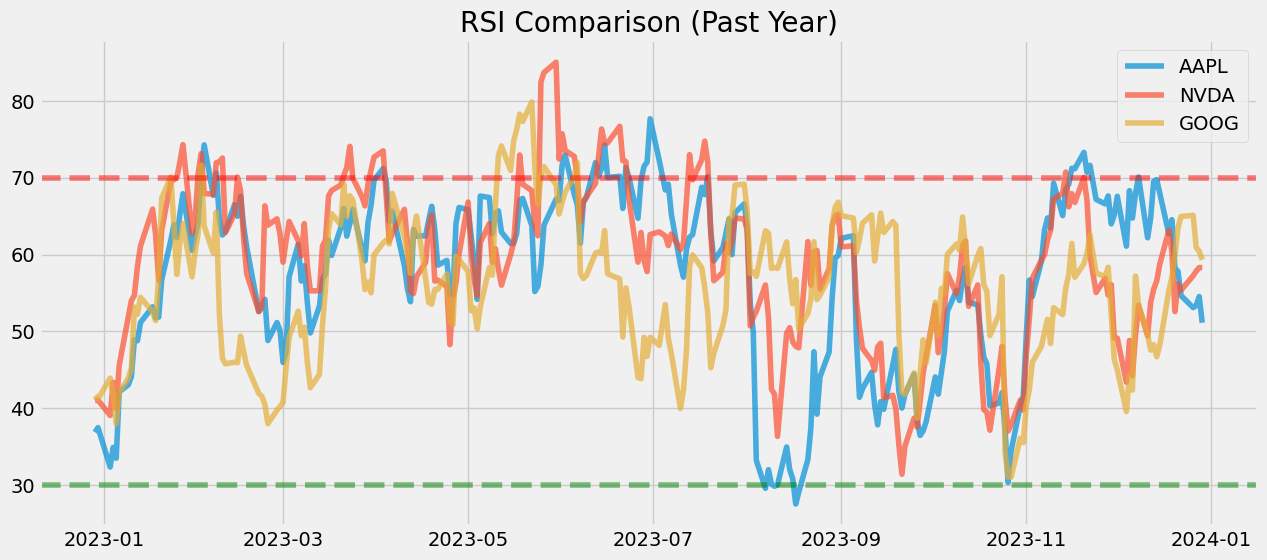

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for ticker in ['AAPL', 'NVDA', 'GOOG']:
    if ticker in stocks:
        ax.plot(stocks[ticker].index[-252:], stocks[ticker]['RSI_14'][-252:], label=ticker, alpha=0.7)

ax.axhline(70, color='red', linestyle='--', alpha=0.5)
ax.axhline(30, color='green', linestyle='--', alpha=0.5)
ax.set_title('RSI Comparison (Past Year)')
ax.legend()
plt.show()

## 5. Detailed Deep Dive: NVIDIA (NVDA)
NVDA has shown extreme volatility. We analyze its price action with MACD and Bollinger Bands.

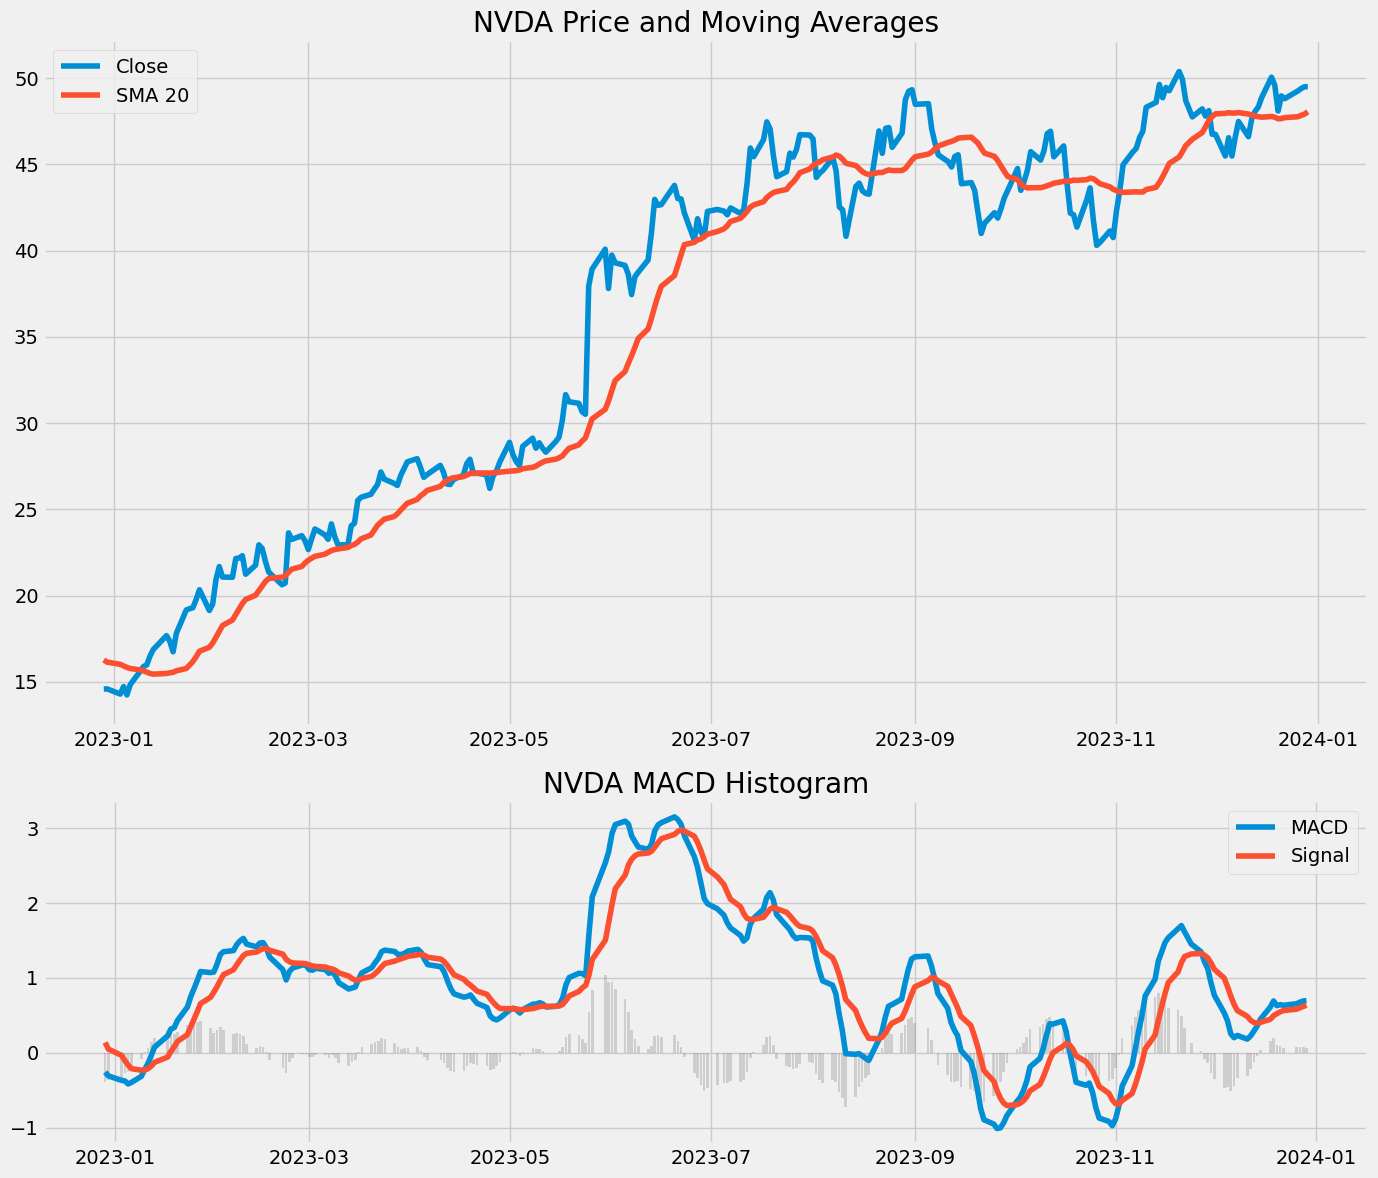

In [6]:
ticker = 'NVDA'
df = stocks[ticker].iloc[-252:] # Last year

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})

# Price and SMA
ax1.plot(df.index, df['Close'], label='Close')
ax1.plot(df.index, df['SMA_20'], label='SMA 20')
ax1.set_title(f'{ticker} Price and Moving Averages')
ax1.legend()

# MACD
macd_col = [c for c in df.columns if 'MACD_12_26_9' in c][0]
signal_col = [c for c in df.columns if 'MACDs_12_26_9' in c][0]
ax2.plot(df.index, df[macd_col], label='MACD')
ax2.plot(df.index, df[signal_col], label='Signal')
ax2.bar(df.index, df[df.columns[df.columns.str.contains('MACDh')][0]], color='gray', alpha=0.3)
ax2.set_title(f'{ticker} MACD Histogram')
ax2.legend()

plt.tight_layout()
plt.show()